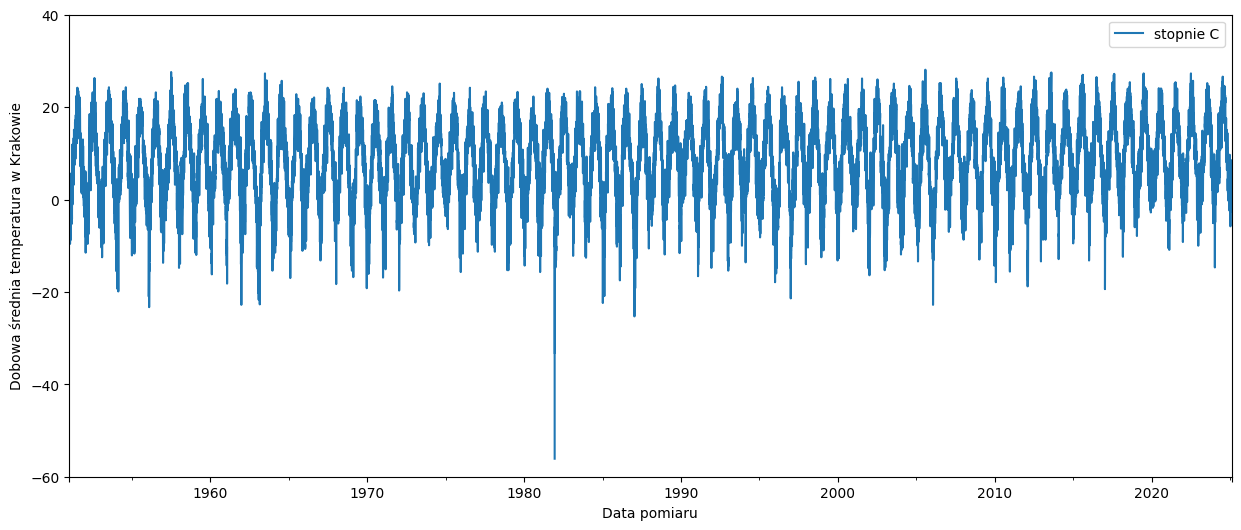

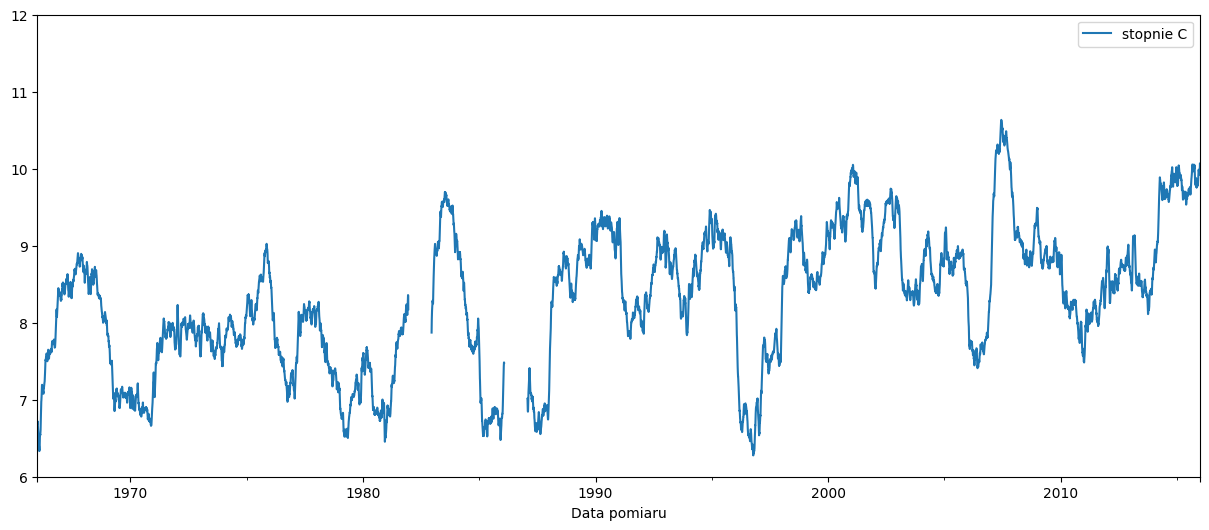

In [1]:
from pandas import read_csv, to_datetime, date_range
from datetime import datetime
from math import nan as NaN
import matplotlib.pyplot as plt

#...

seria = read_csv("full_data.csv", 
                 header = 0, usecols=[1, 2, 3], names=["data", "stopnie C", "q"])

#...

seria = seria.apply(lambda x: to_datetime(x, format="%Y%m%d") if x.name == "data" else x)
seria = seria.apply(lambda x: x/10 if x.name == "stopnie C" else x)
seria = seria.replace(-999.9, NaN)

# Rysujemy wykres na podstawie danych z ramki: na osi x daty, na osi y temperatury, podajemy wielkość wykresu.

seria.plot(x="data", y="stopnie C", figsize=(15,6))

# Ustawiamy etykiety osi wykresu, a także zakresy wartości do pokazania. Pokazujemy wykres.

plt.ylabel("Dobowa średnia temperatura w Krakowie")
plt.xlabel("Data pomiaru")
plt.ylim(-60, 40)
# plt.xlim('1980-01-01', '1984-12-31')
plt.show()

# Wyliczamy i kreślimy średnią kroczącą

seria["stopnie C"] = seria["stopnie C"].rolling(365).mean()



seria.plot(x="data", y="stopnie C", figsize=(15,6))

plt.xlabel("Średnia krocząca o oknie 365")
plt.xlabel("Data pomiaru")
plt.xlim('1966-01-01', '2015-12-31')
plt.ylim(6, 12)
plt.show()
